
Sequence length : 12 steps of dimension 3
Final cell state c_T : [-0.354  0.17  -0.007 -0.171]
Final hidden state h_T: [-0.195  0.073 -0.004 -0.039]



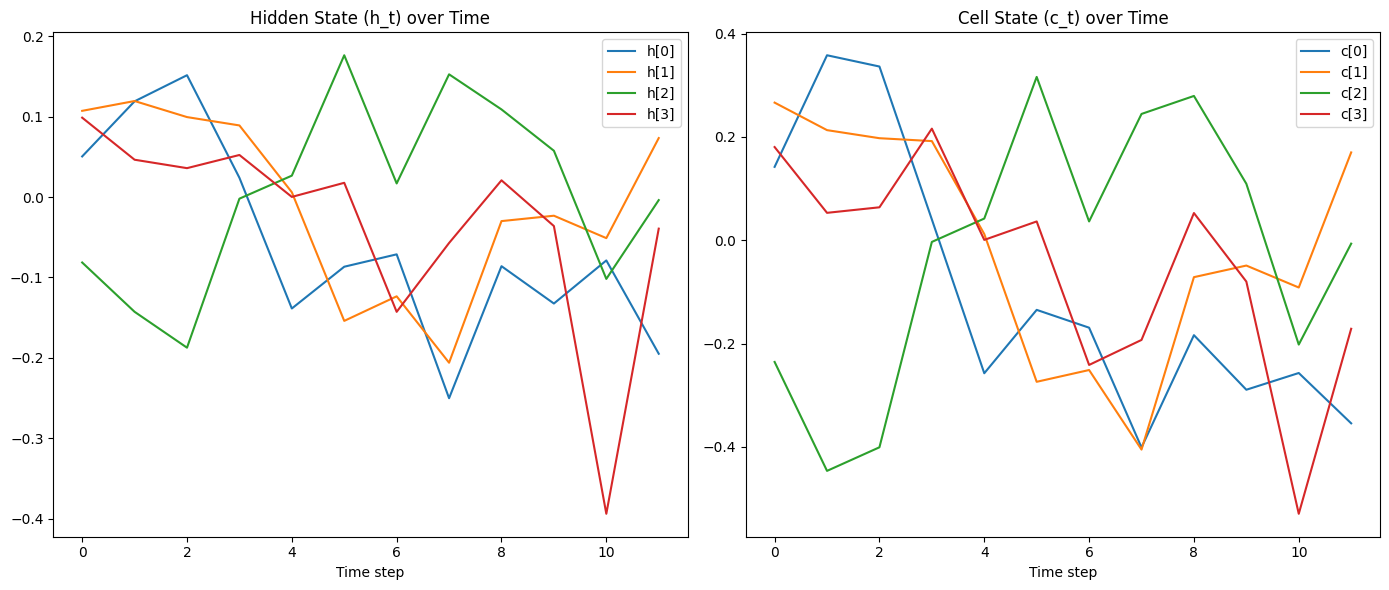

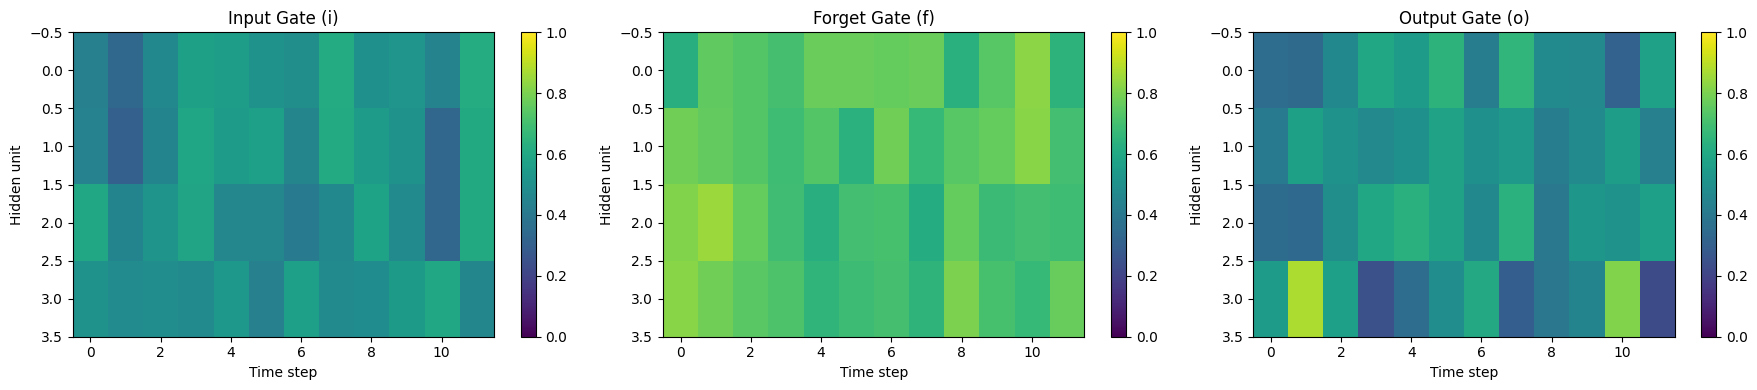

In [6]:
"""
LSTM From Scratch (NumPy) + State Visualization (Refactored)
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Reproducibility ───────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
SEQ_LEN    = 12
INPUT_DIM  = 3
HIDDEN_DIM = 4

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ── LSTM Class Definition ─────────────────────────────────────────────────────
class LSTM:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        concat_dim = input_dim + hidden_dim
        scale = 0.35

        # Weights
        self.W_i = rng.normal(scale=scale, size=(concat_dim, hidden_dim))
        self.W_f = rng.normal(scale=scale, size=(concat_dim, hidden_dim))
        self.W_g = rng.normal(scale=scale, size=(concat_dim, hidden_dim))
        self.W_o = rng.normal(scale=scale, size=(concat_dim, hidden_dim))

        # Biases
        self.b_i = np.zeros(hidden_dim)
        # BEST PRACTICE: Initialize forget gate bias to 1.0 to encourage early memory
        self.b_f = np.ones(hidden_dim)
        self.b_g = np.zeros(hidden_dim)
        self.b_o = np.zeros(hidden_dim)

    def step(self, x_t, h_prev, c_prev):
        """Processes a single time step."""
        xh = np.concatenate([x_t, h_prev])

        # Core LSTM equations with biases included
        i = sigmoid(xh @ self.W_i + self.b_i)
        f = sigmoid(xh @ self.W_f + self.b_f)
        g = np.tanh(xh @ self.W_g + self.b_g)  # Candidate cell state
        o = sigmoid(xh @ self.W_o + self.b_o)

        c_t = f * c_prev + i * g
        h_t = o * np.tanh(c_t)

        return h_t, c_t, i, f, o

    def forward(self, sequence):
        """Processes a full sequence."""
        h = np.zeros(self.hidden_dim)
        c = np.zeros(self.hidden_dim)

        H, C, I, F, O = [], [], [], [], []

        for x_t in sequence:
            h, c, i, f, o = self.step(x_t, h, c)

            H.append(h.copy())
            C.append(c.copy())
            I.append(i.copy())
            F.append(f.copy())
            O.append(o.copy())

        return np.array(H), np.array(C), np.array(I), np.array(F), np.array(O), h, c


# ── Visualization helpers ─────────────────────────────────────────────────────
def plot_states(H, C):
    timesteps = np.arange(len(H))
    plt.figure(figsize=(14,6))

    # Hidden state evolution
    plt.subplot(1, 2, 1)
    for idx in range(H.shape[1]):
        plt.plot(timesteps, H[:, idx], label=f"h[{idx}]")
    plt.title("Hidden State (h_t) over Time")
    plt.xlabel("Time step")
    plt.legend()

    # Cell state evolution
    plt.subplot(1, 2, 2)
    for idx in range(C.shape[1]):
        plt.plot(timesteps, C[:, idx], label=f"c[{idx}]")
    plt.title("Cell State (c_t) over Time")
    plt.xlabel("Time step")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_gates(I, F, O):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    # Using vmin and vmax to lock the colormap between 0 and 1 (sigmoid bounds)
    im0 = axs[0].imshow(I.T, aspect='auto', vmin=0, vmax=1)
    axs[0].set_title("Input Gate (i)")
    fig.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(F.T, aspect='auto', vmin=0, vmax=1)
    axs[1].set_title("Forget Gate (f)")
    fig.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(O.T, aspect='auto', vmin=0, vmax=1)
    axs[2].set_title("Output Gate (o)")
    fig.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.set_xlabel("Time step")
        ax.set_ylabel("Hidden unit")

    plt.tight_layout()
    plt.show()


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Initialize sequence and model
    sequence = rng.normal(size=(SEQ_LEN, INPUT_DIM))
    lstm_model = LSTM(INPUT_DIM, HIDDEN_DIM)

    # Run forward pass
    H, C, I, F, O, final_h, final_c = lstm_model.forward(sequence)

    print(f"\nSequence length : {SEQ_LEN} steps of dimension {INPUT_DIM}")
    print(f"Final cell state c_T : {np.round(final_c, 3)}")
    print(f"Final hidden state h_T: {np.round(final_h, 3)}\n")

    # Visualize internal dynamics
    plot_states(H, C)
    plot_gates(I, F, O)